In [3]:
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [4]:
import numpy as np
import requests
import matplotlib.pyplot as plt
import pandas as p
from IPython.display import display, HTML

%matplotlib inline

planeturl = "https://exo.mast.stsci.edu/api/v0.1/exoplanets/"
dvurl = "https://exo.mast.stsci.edu/api/v0.1/dvdata/tess/"
header={}
from corner import corner

# 1.Set target

In [5]:
planet_name = "WASP-44 b"

url = planeturl + "/identifiers/"

myparams = {"name":planet_name}

r = requests.get(url = url, params = myparams, headers = header)
print(r.headers.get('content-type'))

application/json


If you take a look at the resulting dictionary it includes all the planet Names. It also includes tessID and tessTCE.  These two fields will exist if there is a TCE on this TIC ID with the same period.  We feed these into a variable for later use.

In [6]:
planet_names = r.json()
ticid = planet_names['tessID']
tce = planet_names['tessTCE']
planet_names

{'canonicalName': 'WASP-44 b',
 'starName': 'WASP-44',
 'ra': 3.903208335240682,
 'dec': -11.93813888867696,
 'planetNames': ['GSC 05264-00740 b',
  'UCAC2 27591303 b',
  'UCAC3 157-688 b',
  '2MASS J00153675-1156172 b',
  'WASP-44 b',
  'DENIS J001536.7-115616 b'],
 'keplerID': None,
 'keplerTCE': None,
 'tessID': 12862099,
 'tessTCE': 'TCE_1'}

<a id="prop"></a>
## Get Planet Properties
Get the planet properties for WASP-18 b.  We hold two exoplanet tables, the composite table at NExScI and Exoplanets.org.  If the planet exists in both tables, you will get back an array of dictionaries where the first element is the NExScI's planet properties and the second is Exoplanet.org's properties.

In [7]:
url = planeturl + planet_name + "/properties/"

r = requests.get(url = url, headers = header)

planet_prop = r.json()

print("Catalog 1: " + planet_prop[0]['catalog_name'])
print("Catalog 2: " + planet_prop[1]['catalog_name'])
planet_prop[0].keys()

Catalog 1: exoplanets.org
Catalog 2: nexsci


dict_keys(['canonical_name', 'exoplanetID', 'catalog_name', 'planet_name', 'disposition', 'modified_date', 'star_name', 'component', 'Rs', 'Rs_unit', 'Rs_upper', 'Rs_lower', 'Rs_ref', 'Rs_url', 'Ms', 'Ms_unit', 'Ms_upper', 'Ms_lower', 'Ms_ref', 'Ms_url', 'Fe/H', 'Fe/H_upper', 'Fe/H_lower', 'Fe/H_ref', 'Fe/H_url', 'stellar_gravity', 'stellar_gravity_upper', 'stellar_gravity_lower', 'stellar_gravity_ref', 'stellar_gravity_url', 'Teff', 'Teff_unit', 'Teff_upper', 'Teff_lower', 'Teff_ref', 'Teff_url', 'Vmag', 'Vmag_unit', 'Vmag_upper', 'Vmag_lower', 'Vmag_ref', 'Vmag_url', 'Jmag', 'Jmag_unit', 'Jmag_upper', 'Jmag_lower', 'Jmag_ref', 'Jmag_url', 'Hmag', 'Hmag_unit', 'Hmag_upper', 'Hmag_lower', 'Hmag_ref', 'Hmag_url', 'Kmag', 'Kmag_unit', 'Kmag_upper', 'Kmag_lower', 'Kmag_ref', 'Kmag_url', 'RA', 'DEC', 'distance', 'distance_unit', 'distance_upper', 'distance_lower', 'distance_ref', 'distance_url', 'Rp', 'Rp_unit', 'Rp_upper', 'Rp_lower', 'Rp_ref', 'Rp_url', 'Mp', 'Mp_unit', 'Mp_upper', 'Mp_l

In [8]:
print(planet_name + " Properties")
print("Stellar Mass \t\t%f \t\t%s" % \
      (planet_prop[0]['Ms'], planet_prop[0]['Ms_unit'] ) )
print("Planet Mass \t\t%f \t\t%s" % \
      (planet_prop[0]['Mp'], planet_prop[0]['Mp_unit'] ) )
print("Planet Orbital Period \t%f \t\t%s" % \
      (planet_prop[0]['orbital_period'], \
       planet_prop[0]['orbital_period_unit'] ) )
print("Transit Time \t\t%f \t\t%s" % \
      (planet_prop[0]['transit_time'], \
       planet_prop[0]['transit_time_unit'] ) )
print("Planet Mass Reference: %s" % \
      (planet_prop[0]['Mp_ref']))

# planet_prop[0]['transit_time'] + 0.5

WASP-44 b Properties
Stellar Mass 		0.951000 		M_sun
Planet Mass 		0.889836 		M_Jupiter
Planet Orbital Period 	2.423804 		d
Transit Time 		55433.876000 		MJD
Planet Mass Reference: Calculated from MSINI and I


# 2.Download data

In [7]:
from astroquery.mast import Observations
from astroquery.mast import Catalogs
from astropy.io import fits
from astropy import table
import matplotlib.pyplot as plt
import numpy as np
from copy import deepcopy

## Use Astroquery to find Observations of WASP-
We begin by doing a cone search usig the `Observations.query_object` function and then filtering for time series observations made by TESS. This leaves us with just the TESS 2-minute cadence data observations. 

In [8]:
observations = Observations.query_object(planet_name,radius = "0 deg")
obs_wanted = (observations['dataproduct_type'] \
              == 'timeseries') & (observations['obs_collection'] == 'TESS')
print( observations[obs_wanted]['obs_collection', 'project','obs_id'] )

obs_collection project                      obs_id                    
-------------- ------- -----------------------------------------------
          TESS    TESS tess2018263035959-s0003-0000000012862099-0123-s


## Use Astroquery to Dowload DV Products
Use `Observations.get_product_list` to get a list of data products associated with the observations of interest. Each individual observation is associated with several data products, only some of which are the DV products we are interested in. In this case we want those data products that have "productSubGroupDescription" set to either DVT, DVM, DVS or DVR.  

Next, we use `Observations.download_products` to download our selected data files.  This function returns a manifest, a table that contains the local path to the files that are downloaded.

In [10]:
download_dir = str('./data/' + str(planet_name.replace(' ', '')))
download_dir

'./data/WASP-44b'

In [11]:
data_products = Observations.get_product_list(observations[obs_wanted])
products_wanted = Observations.filter_products(data_products, 
                                    productSubGroupDescription=["DVT","LC"])

print(products_wanted["productFilename"])
manifest = Observations.download_products(products_wanted,download_dir=download_dir)

                       productFilename                       
-------------------------------------------------------------
tess2018263124740-s0003-s0003-0000000012862099-00405_dvt.fits
tess2018267104341-s0003-s0003-0000000012862099-00126_dvt.fits
      tess2018263035959-s0003-0000000012862099-0123-s_lc.fits
INFO: Found cached file ./data/WASP-44b/mastDownload/TESS/tess2018263035959-s0003-0000000012862099-0123-s/tess2018263124740-s0003-s0003-0000000012862099-00405_dvt.fits with expected size 3968640. [astroquery.query]
INFO: Found cached file ./data/WASP-44b/mastDownload/TESS/tess2018263035959-s0003-0000000012862099-0123-s/tess2018267104341-s0003-s0003-0000000012862099-00126_dvt.fits with expected size 2949120. [astroquery.query]
INFO: Found cached file ./data/WASP-44b/mastDownload/TESS/tess2018263035959-s0003-0000000012862099-0123-s/tess2018263035959-s0003-0000000012862099-0123-s_lc.fits with expected size 1998720. [astroquery.query]


## Download Complete
You have now downloaded ALL of the TESS DV products for this star and their locations can be seen by printing the "Local Path" in the manifest.  Notice that because this star was observed in many sectors, there are many different sets of DV products, one set for each range of sectors searched.

In [12]:
print( manifest['Local Path'] )

                                                                   Local Path                                                                  
-----------------------------------------------------------------------------------------------------------------------------------------------
./data/WASP-44b/mastDownload/TESS/tess2018263035959-s0003-0000000012862099-0123-s/tess2018263124740-s0003-s0003-0000000012862099-00405_dvt.fits
./data/WASP-44b/mastDownload/TESS/tess2018263035959-s0003-0000000012862099-0123-s/tess2018267104341-s0003-s0003-0000000012862099-00126_dvt.fits
      ./data/WASP-44b/mastDownload/TESS/tess2018263035959-s0003-0000000012862099-0123-s/tess2018263035959-s0003-0000000012862099-0123-s_lc.fits


In [ ]:
manifest['Local Path'][0]

## Examine the Download Manifest

TESS file names tell you a lot about what is in the file. In the function `parse_manifest` below I break them apart so that I can make an easy to read table about the type of data that we downloaded.  Then we write-out that part of the table.   This makes it obvious that there are lots of different sets of DV files based on different searches, each with a different sector range.  For each sector it was observed, there is a single sector search, and then there are also several multi sector searches.

In [ ]:
def parse_manifest(manifest):
    """
    Parse manifest and add back columns that are useful for TESS DV exploration.
    """
    results = deepcopy(manifest)
    filenames = []
    sector_range = []
    exts = []
    for i,f in enumerate(manifest['Local Path']):
        file_parts = np.array(np.unique(f.split(sep = '-')))
        sectors = list( map ( lambda x: x[0:2] == 's0', file_parts))
        s1 = file_parts[sectors][0]
        try:
            s2 = file_parts[sectors][1]
        except:
            s2 = s1
        sector_range.append("%s-%s" % (s1,s2))
        path_parts = np.array(f.split(sep = '/'))
        filenames.append(path_parts[-1])
        exts.append(path_parts[-1][-8:])

    results.add_column(table.Column(name = "filename", data = filenames))
    results.add_column(table.Column(name = "sectors", data = sector_range))
    results.add_column(table.Column(name = "fileType", data = exts))
    results.add_column(table.Column(name = "index", data = np.arange(0,len(manifest))))
    
    return results

#Run parser and print
results = parse_manifest(manifest)
print(results['index','sectors','fileType'])

In [9]:
import pandas as pd
import seaborn as sb

from pathlib import Path
from uncertainties import ufloat
from scipy.stats import norm

from pytransit.lpf.tesslpf import TESSLPF, fold, downsample_time, BaseLPF
from pytransit.orbits import epoch
from tqdm.notebook import tqdm as tqdm

In [10]:
npop         = 30
mcmc_repeats = 4
datadir = 'data/WASP-44b/mastDownload/TESS/tess2018263035959-s0003-0000000012862099-0123-s/'

transit_time = planet_prop[0]['transit_time'] + 0.5 + 2.4e6
transit_time_err = max(planet_prop[0]['transit_time_lower'],planet_prop[0]['transit_time_upper'])
orbital_period = planet_prop[0]['orbital_period']
orbital_period_err = max(planet_prop[0]['orbital_period_lower'],planet_prop[0]['orbital_period_upper'])

# zero_epoch = ufloat(transit_time,transit_time_err)
# period = ufloat(orbital_period,orbital_period_err)

zero_epoch = ufloat(transit_time,transit_time_err)
period = ufloat(orbital_period,orbital_period_err)

In [11]:
print(zero_epoch,period)

2455434.3760+/-0.0004 2.423804+/-0.000009


In [12]:
lpf = TESSLPF(planet_name,datadir,tic=ticid,zero_epoch=zero_epoch.n,period=period.n,use_pdc=True,nsamples=2, bldur=0.25)
ep = epoch(lpf.times[0].mean(), lpf.zero_epoch, lpf.period)
tc = zero_epoch + ep*period

lpf.set_prior('tc', 'NP', tc.n,     0.05)          # Wide normal prior on the transit center
lpf.set_prior('p',  'NP', period.n, period.s)  # Wide normal prior on the orbital period
lpf.set_prior('rho', 'UP', 0, 1)               # Uniform prior on the stellar density
lpf.set_prior('k2', 'UP', 0.0, 0.2**2)             # Uniform prior on the area ratio
lpf.set_prior('gp_ln_in', 'UP', -2, 1)             # Uniform prior on the GP input scale

### Print the model parameters

In [13]:
lpf.print_parameters(columns=1)

  0 |G| tc             N(μ = 2458386.5691502, σ = 0.05)         [    -inf ..      inf]
  1 |G| p              N(μ = 2.4238039000000002, σ = 8.7e-06)   [    0.00 ..      inf]
  2 |G| rho            U(a = 0, b = 1)                          [    0.00 ..      inf]
  3 |G| b              U(a = 0.0, b = 1.0)                      [    0.00 ..     1.00]
  4 |P| k2             U(a = 0.0, b = 0.04000000000000001)      [    0.00 ..      inf]
  5 |P| q1_TESS        U(a = 0, b = 1)                          [    0.00 ..     1.00]
  6 |P| q2_TESS        U(a = 0, b = 1)                          [    0.00 ..     1.00]
  7 |L| gp_ln_out      N(μ = -6.0, σ = 1.5)                     [    -inf ..      inf]
  8 |L| gp_ln_in       U(a = -2, b = 1)                         [    -inf ..      inf]
  9 |L| gp_log10_wn    N(μ = -2.378200919186614, σ = 0.025)     [    -inf ..      inf]


## Global optimisation

We'll start with a global optimisation run to clump the parameter vector population near the global posterior mode and plot the mode.

This can be done semi-interactively. That is, first run the optimiser (evaluate the cell below) with a small (100-300) number of iterations and plot the folded transit. Then run the optimiser again (re-evaluate the cell below, and the optimiser continues from where it left) and replot the folded transit. After it's clear that the optimiser is converging to a sensible solution, run the optimiser longer (possibly until it stops).

**Note:** The parameter vector population size `npop` should be at least twice the number of free parameters (`len(lpf.ps)`).

Global optimisation:   0%|          | 0/150 [00:00<?, ?it/s]

/home/troy/.local/lib/python3.9/site-packages/pytransit/lpf/lpf.py:434: RuntimeWarning: invalid value encountered in sqrt
  radius_ratio = sqrt(pv[:,4:5])


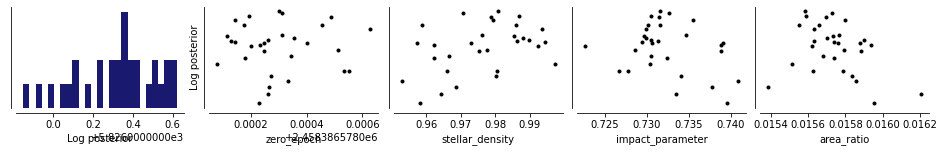

In [14]:
lpf.optimize_global(150, npop=npop)

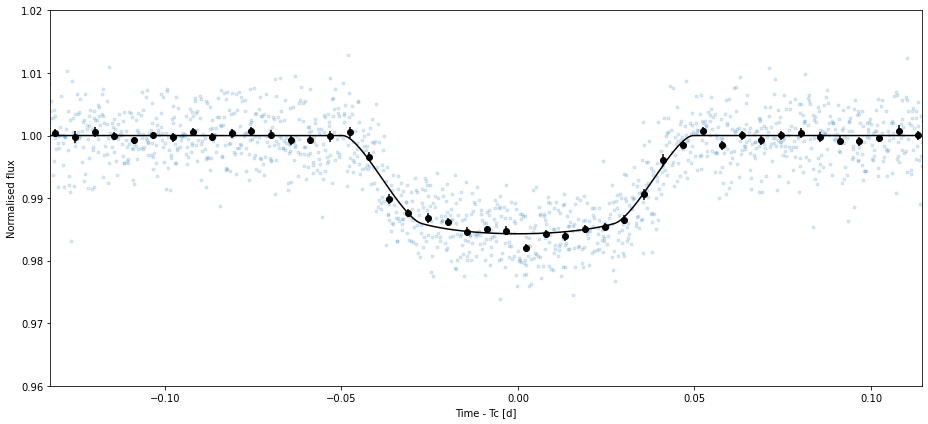

In [15]:
lpf.plot_folded_transit(ylim=(0.96, 1.02));

## MCMC

### Sample the posterior
We continue with an MCMC run, using the global optimisation population as the MCMC starting population. The MCMC sampling consists of a set of wamp-up runs where each run is started from the parameter vector population of the previous run's last iteration, and the chains from the previous run are discarded.

In [16]:
lpf.sample_mcmc(2500, thin=25, repeats=mcmc_repeats)

MCMC sampling:   0%|          | 0/4 [00:00<?, ?it/s]

Run 1/4:   0%|          | 0/2500 [00:00<?, ?it/s]

Run 2/4:   0%|          | 0/2500 [00:00<?, ?it/s]

Run 3/4:   0%|          | 0/2500 [00:00<?, ?it/s]

Run 4/4:   0%|          | 0/2500 [00:00<?, ?it/s]

## Analysis
### Plot the posterior model

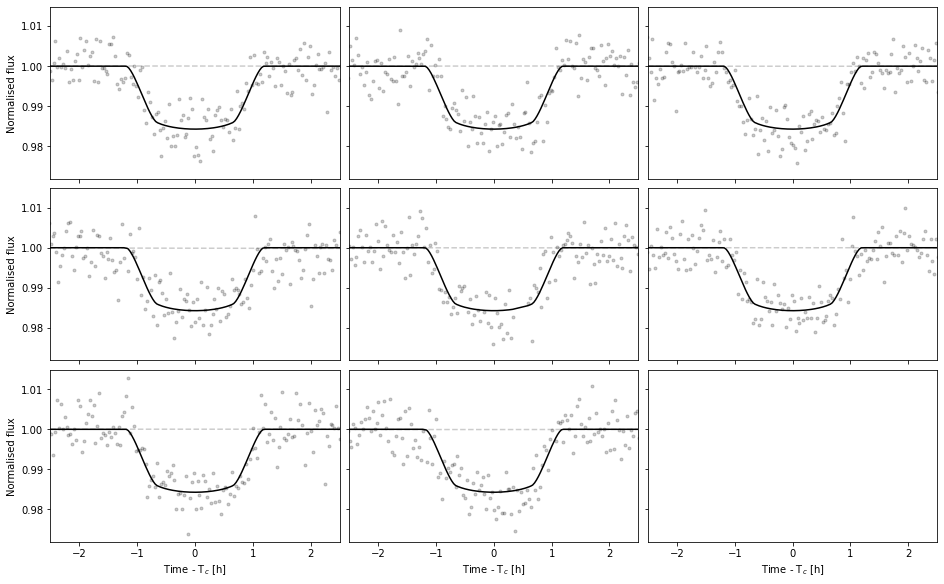

In [17]:
fig = lpf.plot_individual_transits(ncols=3, figsize=(13,8), xlim=(-2.5,2.5))

### Plot the posterior transit centre

### The default corner plot

Everyone likes corner plots, so let's do one for the main parameters.

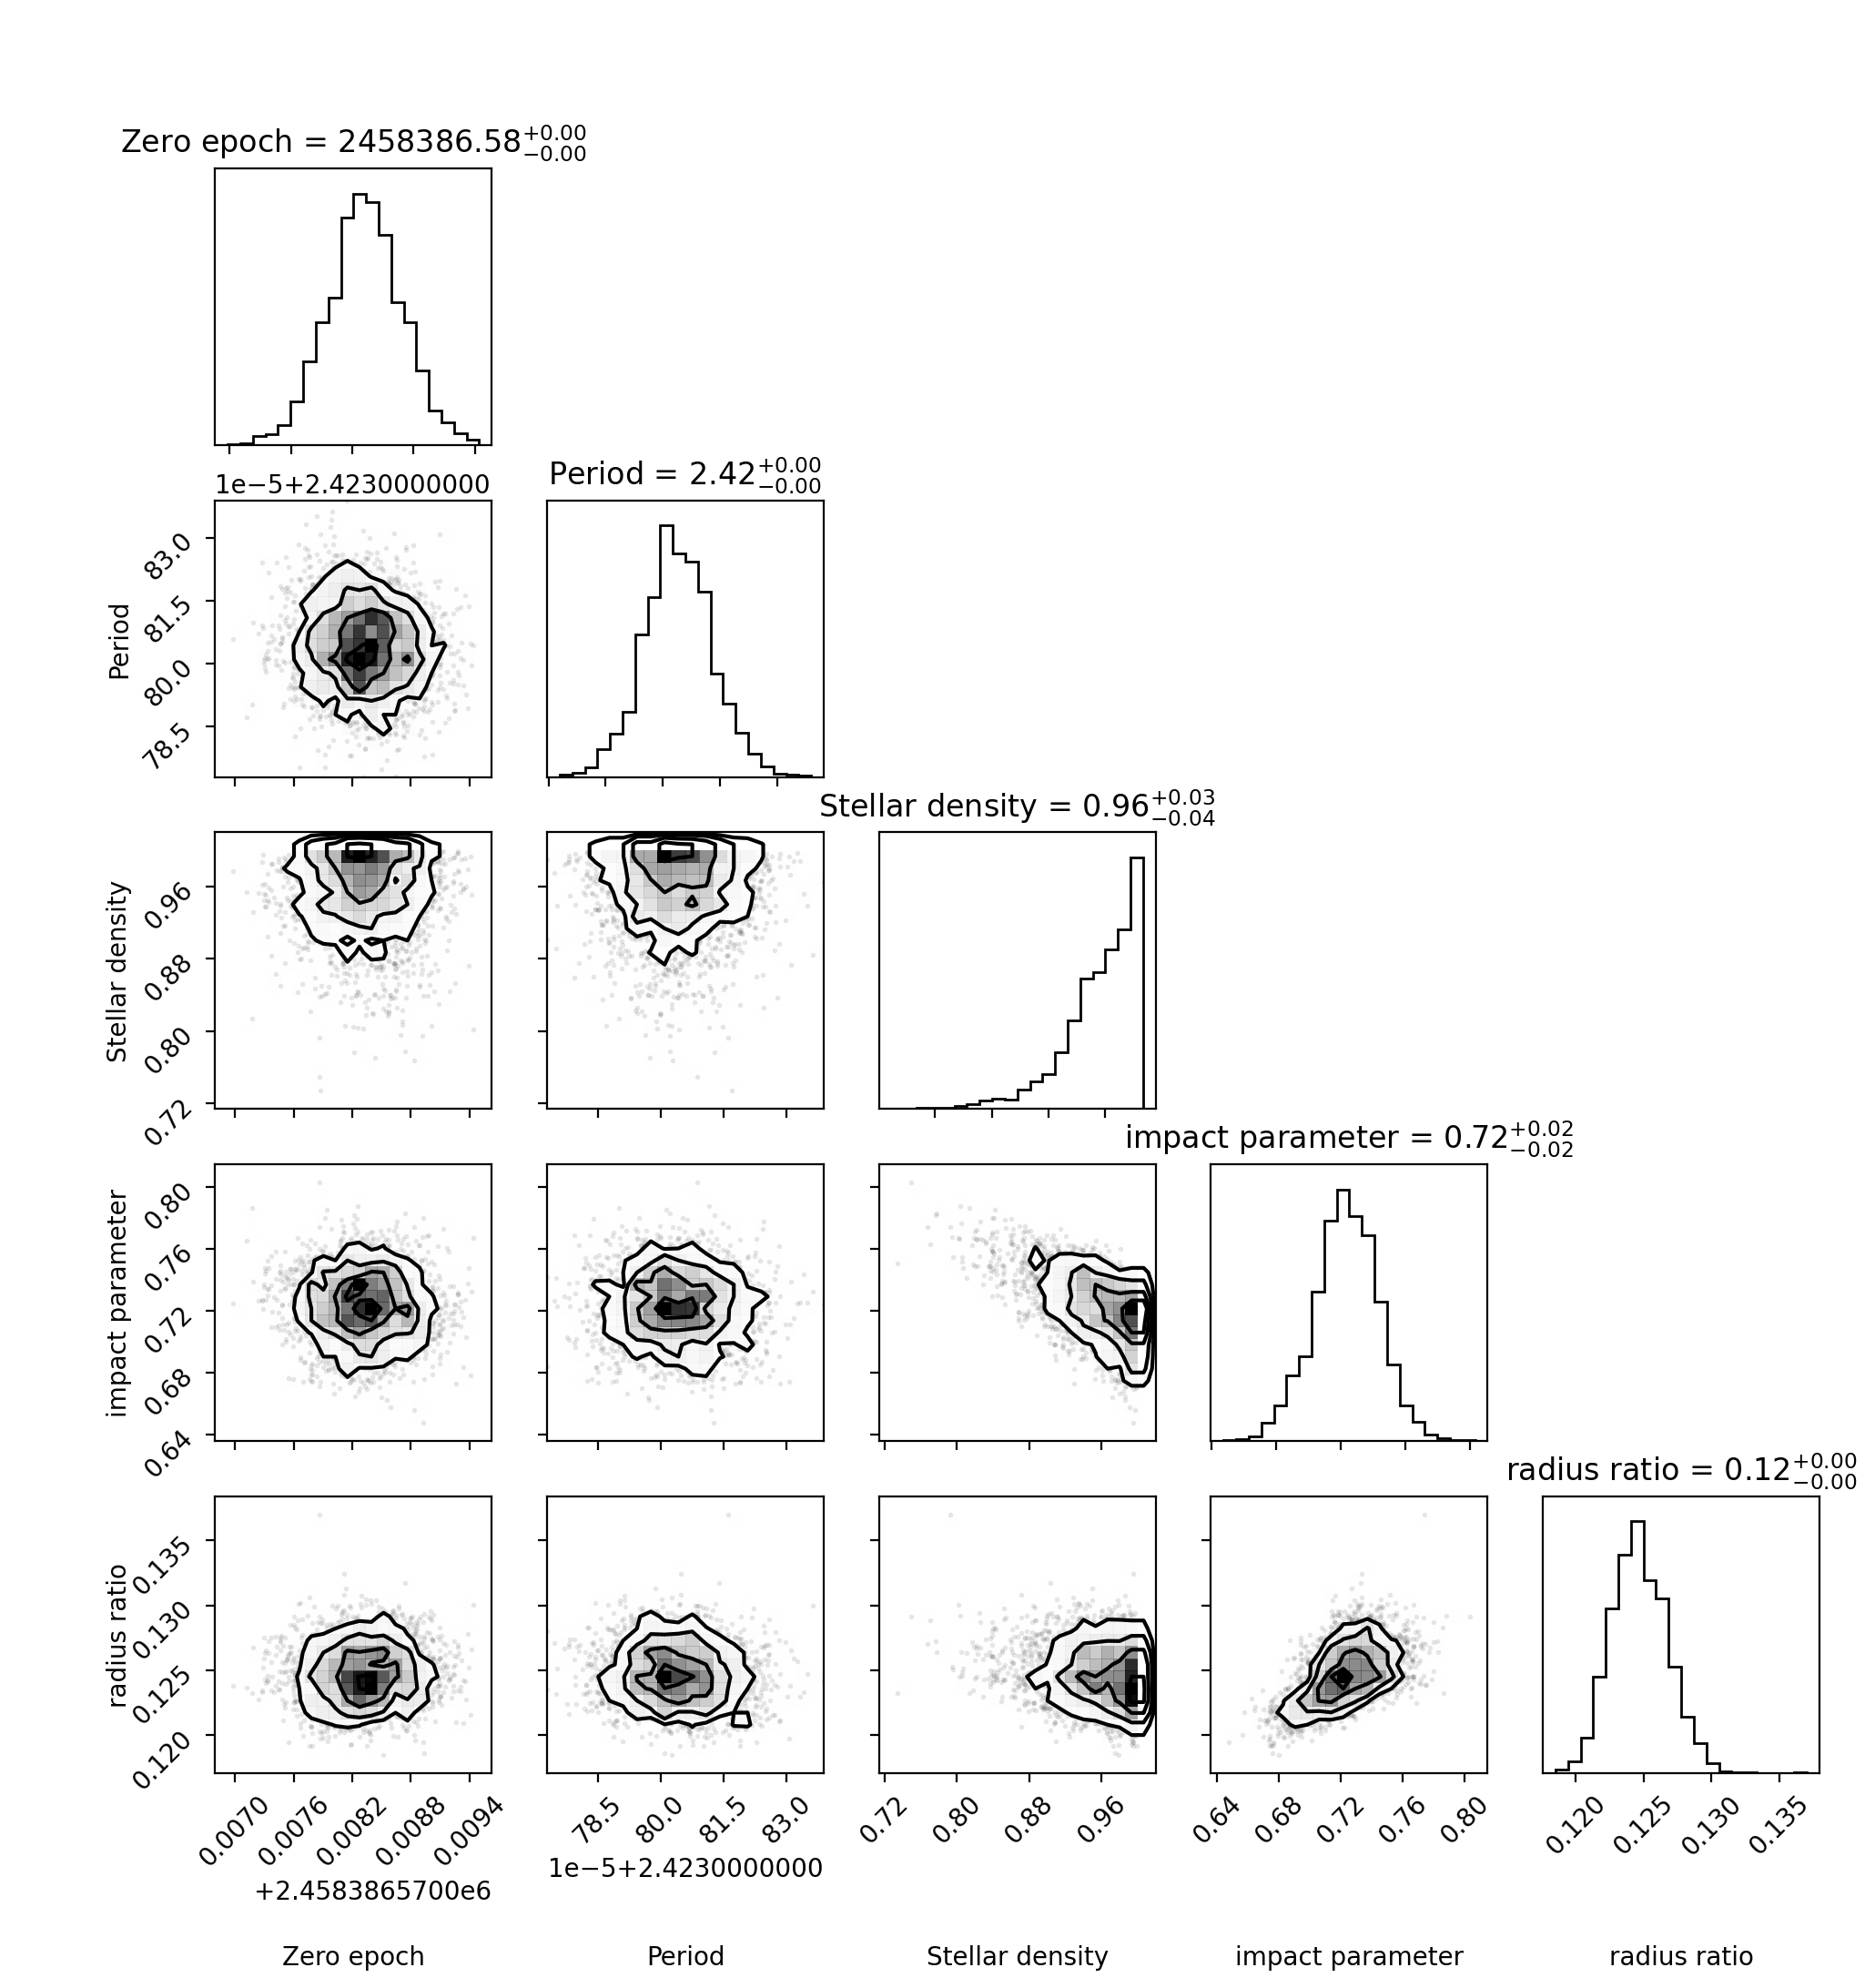

In [18]:
from corner import corner

fig,ax = plt.subplots(5,5,figsize=(10,10),dpi=200)


df = lpf.posterior_samples()
corner(df['tc p rho b k'.split()],
labels='\n\n\nZero epoch, \n\n\nPeriod, \n\n\nStellar density, \n\n\nimpact parameter, \n\n\nradius ratio'.split(', '),fig=fig,show_titles=True)

plt.subplots_adjust(wspace=0.2,hspace=0.2)

plt.savefig('image/corner.pdf',bbox_inches='tight')
plt.show()

In [19]:
times = lpf.times
fluxes = lpf.fluxes
errors = lpf.errors

In [20]:
class singlefit(BaseLPF):
    
    def plot_folded_transit(self, method='de', figsize=(13, 6), ylim=(0.9975, 1.002), xlim=None, binwidth=8,
                            remove_baseline: bool = False):
        if method == 'de':
            pv = self.de.minimum_location
            tc, p = pv[[0, 1]]
        else:
            raise NotImplementedError

        phase = p * fold(self.timea, p, tc, 0.5)
        binwidth = binwidth / 24 / 60
        sids = argsort(phase)

        tm = self.transit_model(pv)

        if remove_baseline:
            gp = self._lnlikelihood_models[0]
            bl = squeeze(gp.predict_baseline(pv))
        else:
            bl = ones_like(self.ofluxa)

        bp, bfo, beo = downsample_time(phase[sids], (self.ofluxa / bl)[sids], binwidth)

        fig, ax = subplots(figsize=figsize)
        ax.plot(phase - 0.5 * p, self.ofluxa / bl, '.', alpha=0.15)
        ax.errorbar(bp - 0.5 * p, bfo, beo, fmt='ko')
        ax.plot(phase[sids] - 0.5 * p, tm[sids], 'k')
        xlim = xlim if xlim is not None else 1.01 * (bp[isfinite(bp)][[0, -1]] - 0.5 * p)
        setp(ax, ylim=ylim, xlim=xlim, xlabel='Time - Tc [d]', ylabel='Normalised flux')
        fig.tight_layout()
        return fig
    
    def plot_corner(self):

        fig,ax = plt.subplots(5,5,figsize=(10,10),dpi=200)


        df = self.posterior_samples()
        corner(df['tc p rho b k'.split()],
        labels='\n\n\nZero epoch, \n\n\nPeriod, \n\n\nStellar density, \n\n\nimpact parameter, \n\n\nradius ratio'.split(', '),fig=fig,show_titles=True)

        plt.subplots_adjust(wspace=0.2,hspace=0.2)

        return fig

In [21]:
i = 6


test = singlefit('WASP-44 b',None,times[i],fluxes[i])
ep = epoch(test.timea.mean(), zero_epoch.n, period.n)
tc = zero_epoch + ep*period

test.set_prior('tc', 'NP', tc.n,     tc.s)          # Wide normal prior on the transit center
test.set_prior('p',  'NP', period.n, period.s)  # Wide normal prior on the orbital period
test.set_prior('rho', 'UP', 0, 1)               # Uniform prior on the stellar density
test.set_prior('k2', 'UP', 0.0, 0.2**2)             # Uniform prior on the area ratio
# test.set_prior('gp_ln_in', 'UP', -2, 1)             # Uniform prior on the GP input scale

Global optimisation:   0%|          | 0/100 [00:00<?, ?it/s]

/home/troy/.local/lib/python3.9/site-packages/pytransit/lpf/lpf.py:434: RuntimeWarning: invalid value encountered in sqrt
  radius_ratio = sqrt(pv[:,4:5])


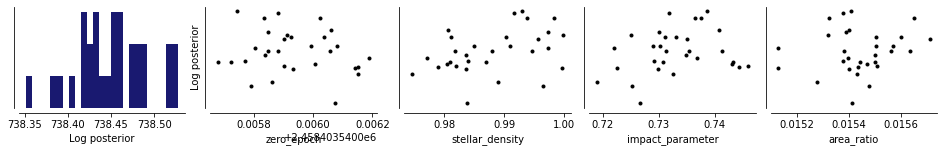

In [22]:
test.optimize_global(100, npop=npop)

In [9]:
test.sample_mcmc(2500, thin=25, repeats=mcmc_repeats)

NameError: name 'test' is not defined

In [24]:
tc

2458403.5357775004+/-0.010665003809188256

In [25]:
test.print_parameters(1)

  0 |G| tc             N(μ = 2458403.5357775004, σ = 0.010665003809188256) [    -inf ..      inf]
  1 |G| p              N(μ = 2.4238039000000002, σ = 8.7e-06)   [    0.00 ..      inf]
  2 |G| rho            U(a = 0, b = 1)                          [    0.00 ..      inf]
  3 |G| b              U(a = 0.0, b = 1.0)                      [    0.00 ..     1.00]
  4 |P| k2             U(a = 0.0, b = 0.04000000000000001)      [    0.00 ..      inf]
  5 |P| q1_None        U(a = 0, b = 1)                          [    0.00 ..     1.00]
  6 |P| q2_None        U(a = 0, b = 1)                          [    0.00 ..     1.00]
  7 |L| wn_loge_0      U(a = -4, b = 0)                         [    -inf ..      inf]


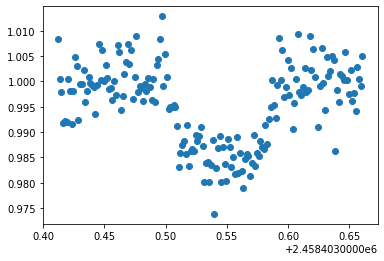

In [26]:
plt.scatter(test.timea,test.ofluxa)

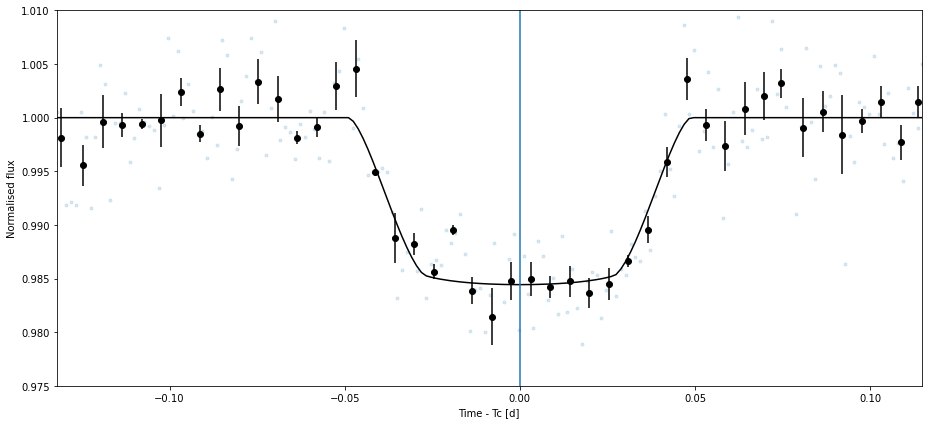

In [37]:
fig = test.plot_folded_transit(ylim=(0.975,1.01))
plt.axvline(0)

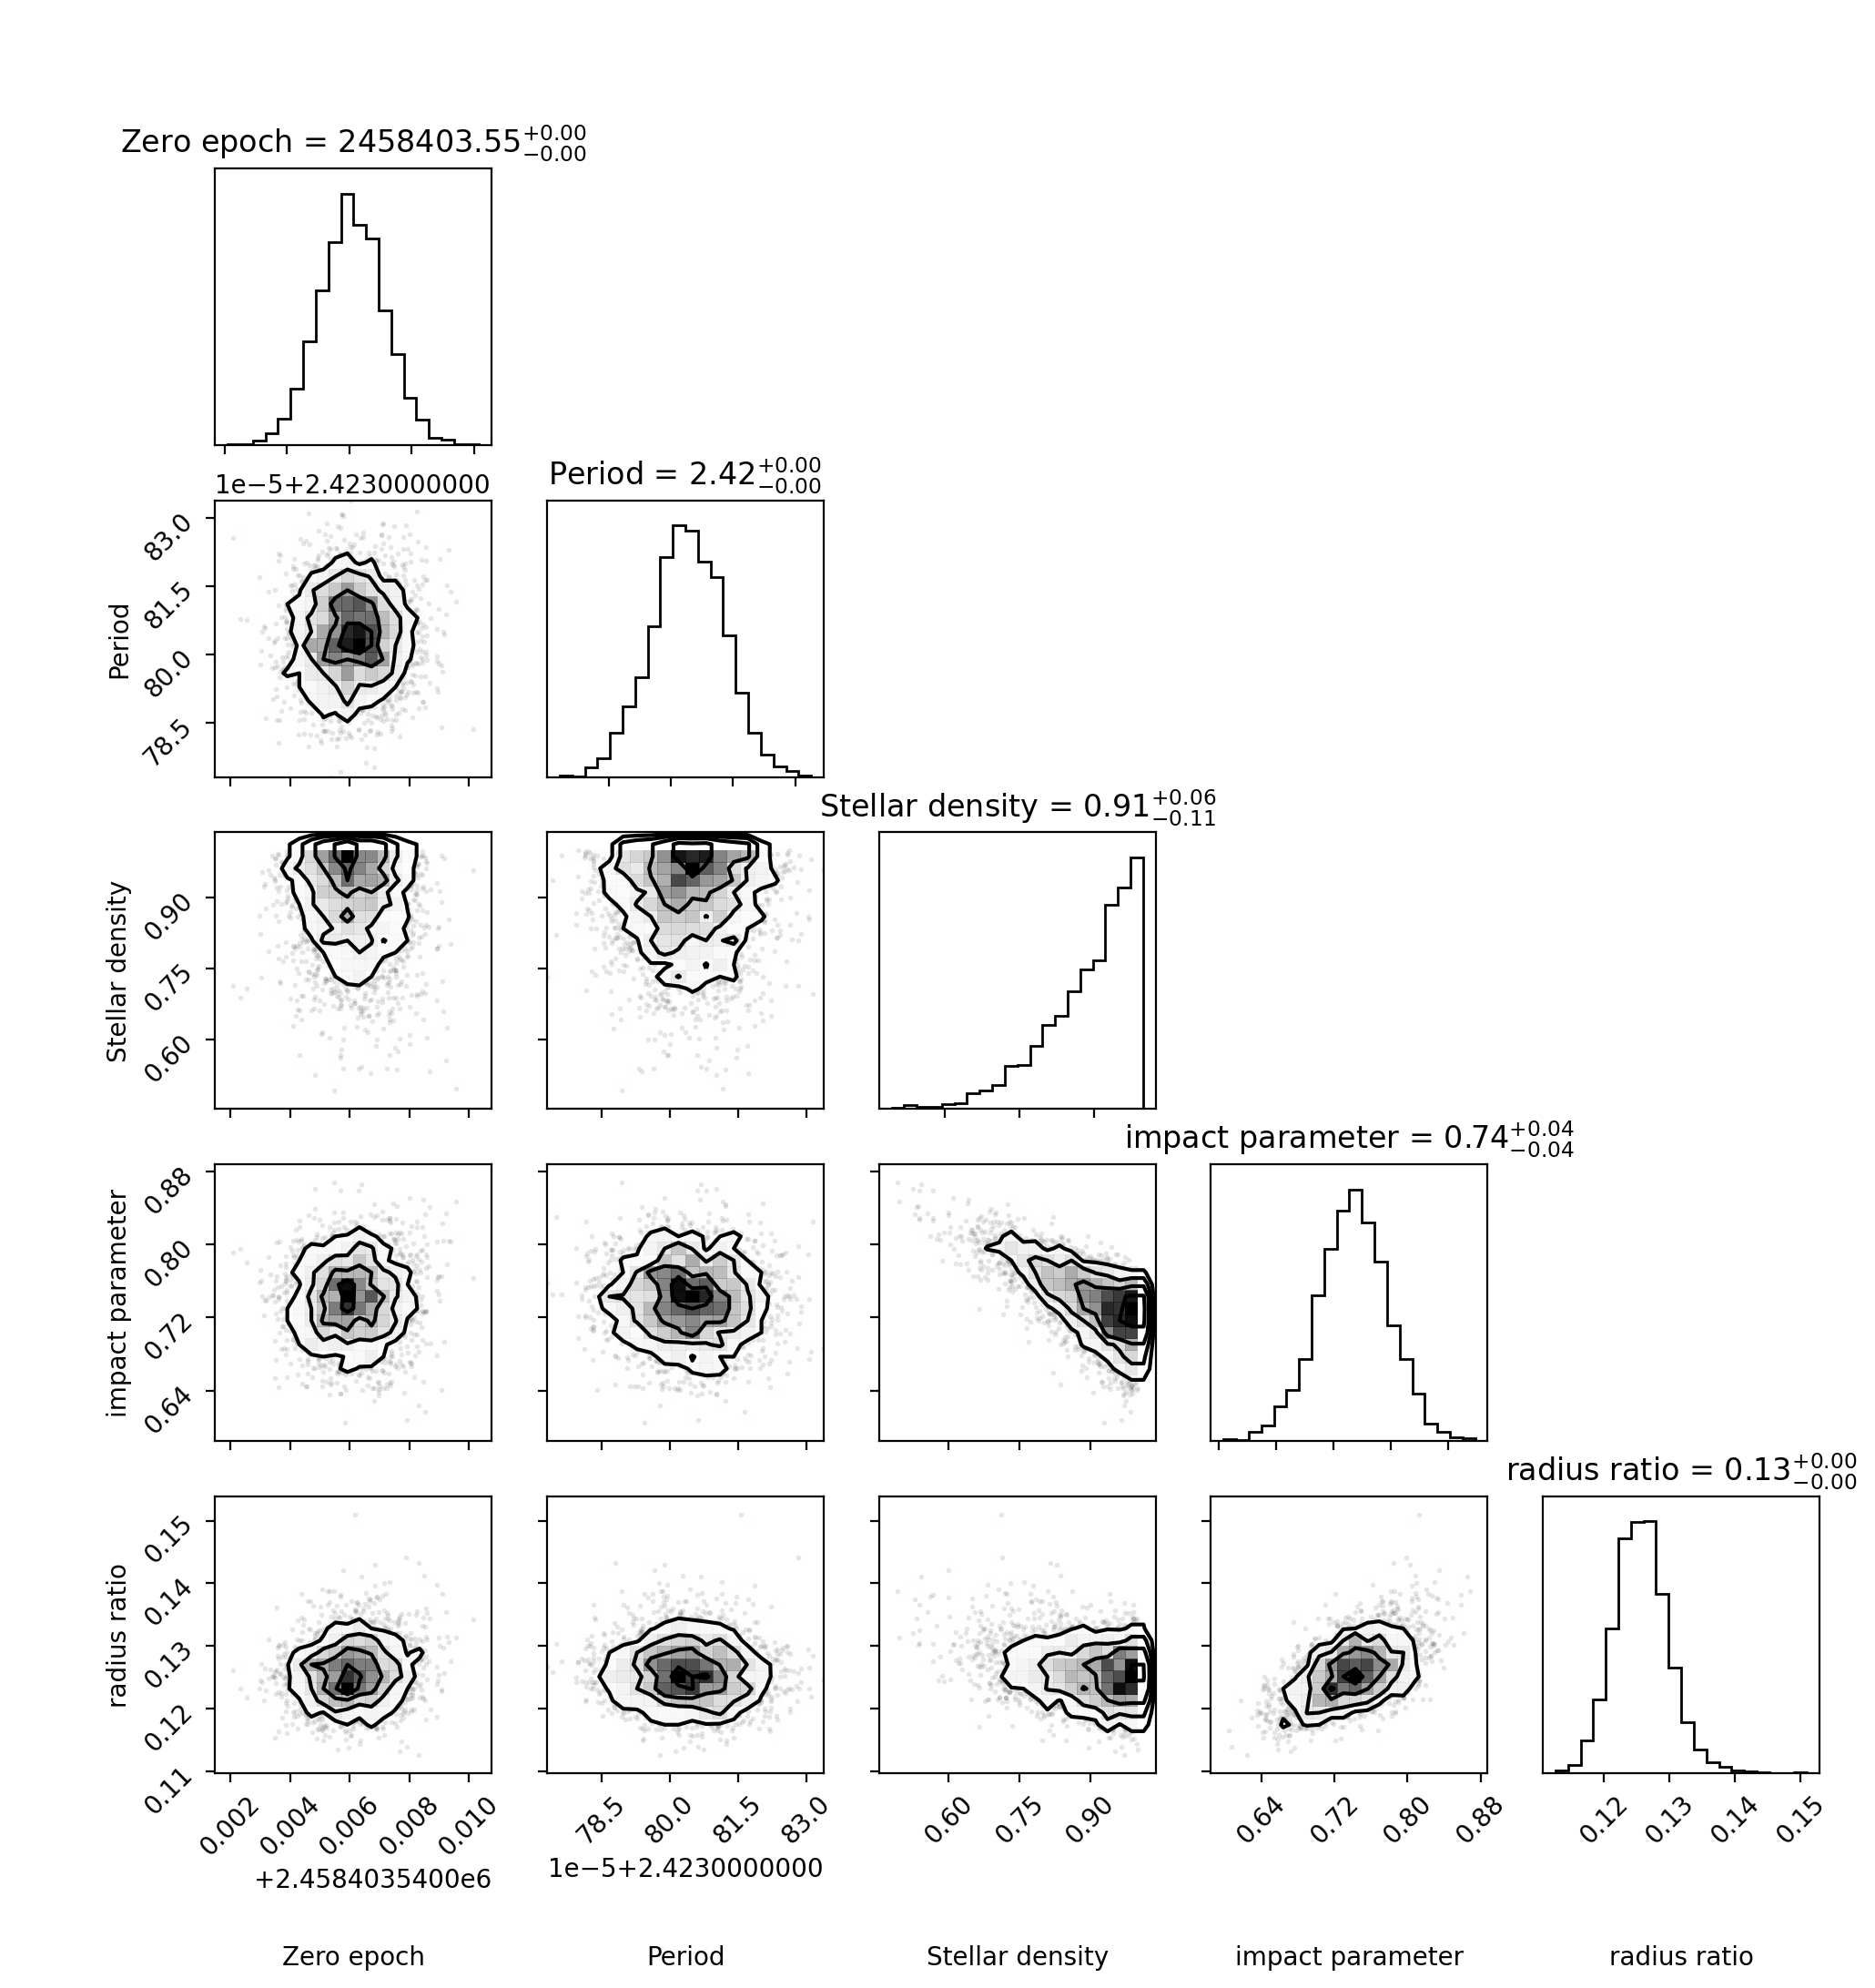

In [28]:
fig = test.plot_corner()

In [29]:
def getTc(i):


    test = singlefit('WASP-44 b -' + str(i) + 'th',None,times[i],fluxes[i])
    ep = epoch(test.timea.mean(), zero_epoch.n, period.n)
    tc = zero_epoch + ep*period

    test.set_prior('tc', 'NP', tc.n,     tc.s)          # Wide normal prior on the transit center
    test.set_prior('p',  'NP', period.n, period.s)  # Wide normal prior on the orbital period
    test.set_prior('rho', 'UP', 0, 1)               # Uniform prior on the stellar density
    test.set_prior('k2', 'UP', 0.0, 0.2**2)             # Uniform prior on the area ratio
    # test.set_prior('gp_ln_in', 'UP', -2, 1)             # Uniform prior on the GP input scale
    
    test.optimize_global(100, npop=npop)
    test.sample_mcmc(2500, thin=25, repeats=mcmc_repeats)
    df = test.posterior_samples()
    
    return ufloat(df.tc.mean(),df.tc.std())

In [30]:
getTc_v = np.vectorize(getTc)

Global optimisation:   0%|          | 0/100 [00:00<?, ?it/s]

/home/troy/.local/lib/python3.9/site-packages/pytransit/lpf/lpf.py:434: RuntimeWarning: invalid value encountered in sqrt
  radius_ratio = sqrt(pv[:,4:5])


MCMC sampling:   0%|          | 0/4 [00:00<?, ?it/s]

Run 1/4:   0%|          | 0/2500 [00:00<?, ?it/s]

Run 2/4:   0%|          | 0/2500 [00:00<?, ?it/s]

...

Run 1/4:   0%|          | 0/2500 [00:00<?, ?it/s]

/home/troy/.local/lib/python3.9/site-packages/pytransit/lpf/lpf.py:434: RuntimeWarning: invalid value encountered in sqrt
  radius_ratio = sqrt(pv[:,4:5])


Run 2/4:   0%|          | 0/2500 [00:00<?, ?it/s]

Run 3/4:   0%|          | 0/2500 [00:00<?, ?it/s]

Run 4/4:   0%|          | 0/2500 [00:00<?, ?it/s]

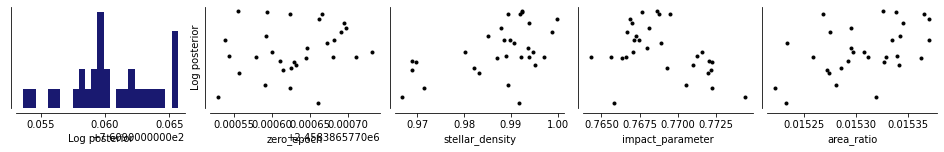

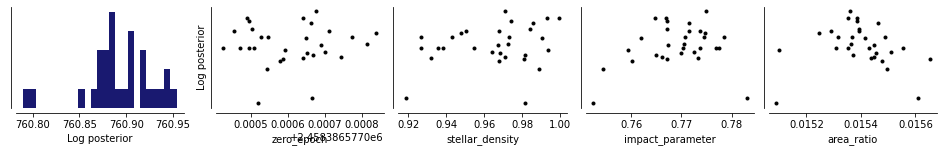

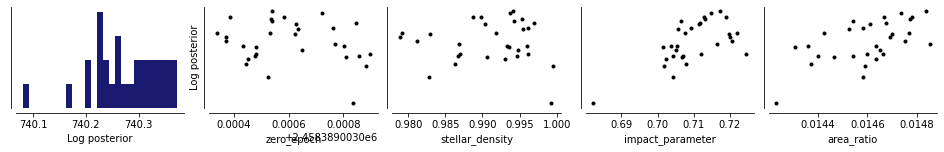

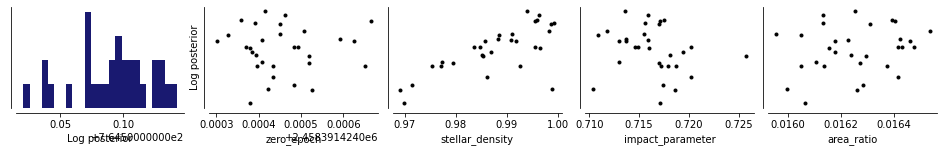

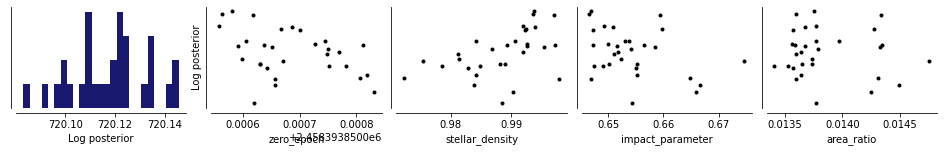

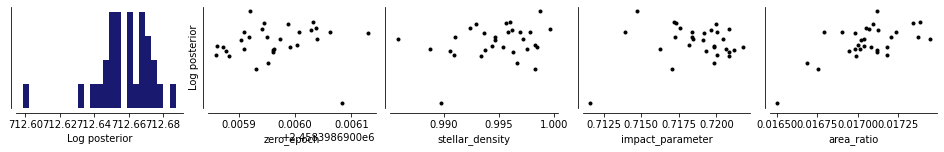

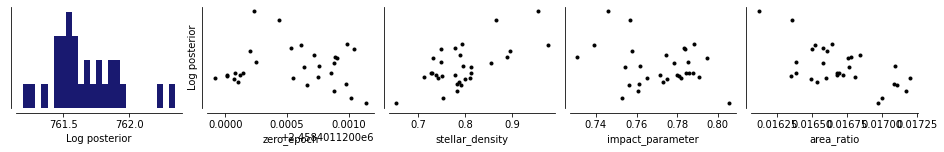

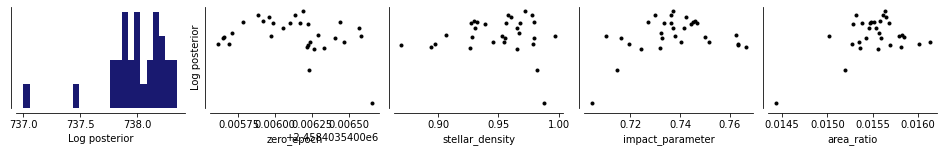

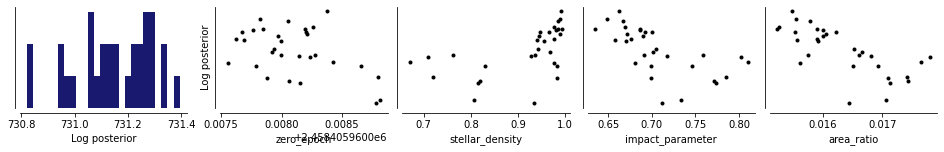

In [31]:
tcs = getTc_v(np.arange(8))

In [32]:
tcs

array([2458386.577511329+/-0.0011017347411487015,
       2458389.0037092296+/-0.0011114341957016707,
       2458391.424547359+/-0.0009615400611036598,
       2458393.8505140087+/-0.0017039595127018954,
       2458398.696284762+/-0.00111600517353893,
       2458401.1208844017+/-0.0011049556958639866,
       2458403.5461356123+/-0.001058809452499662,
       2458405.9682149794+/-0.0013058569440545535], dtype=object)

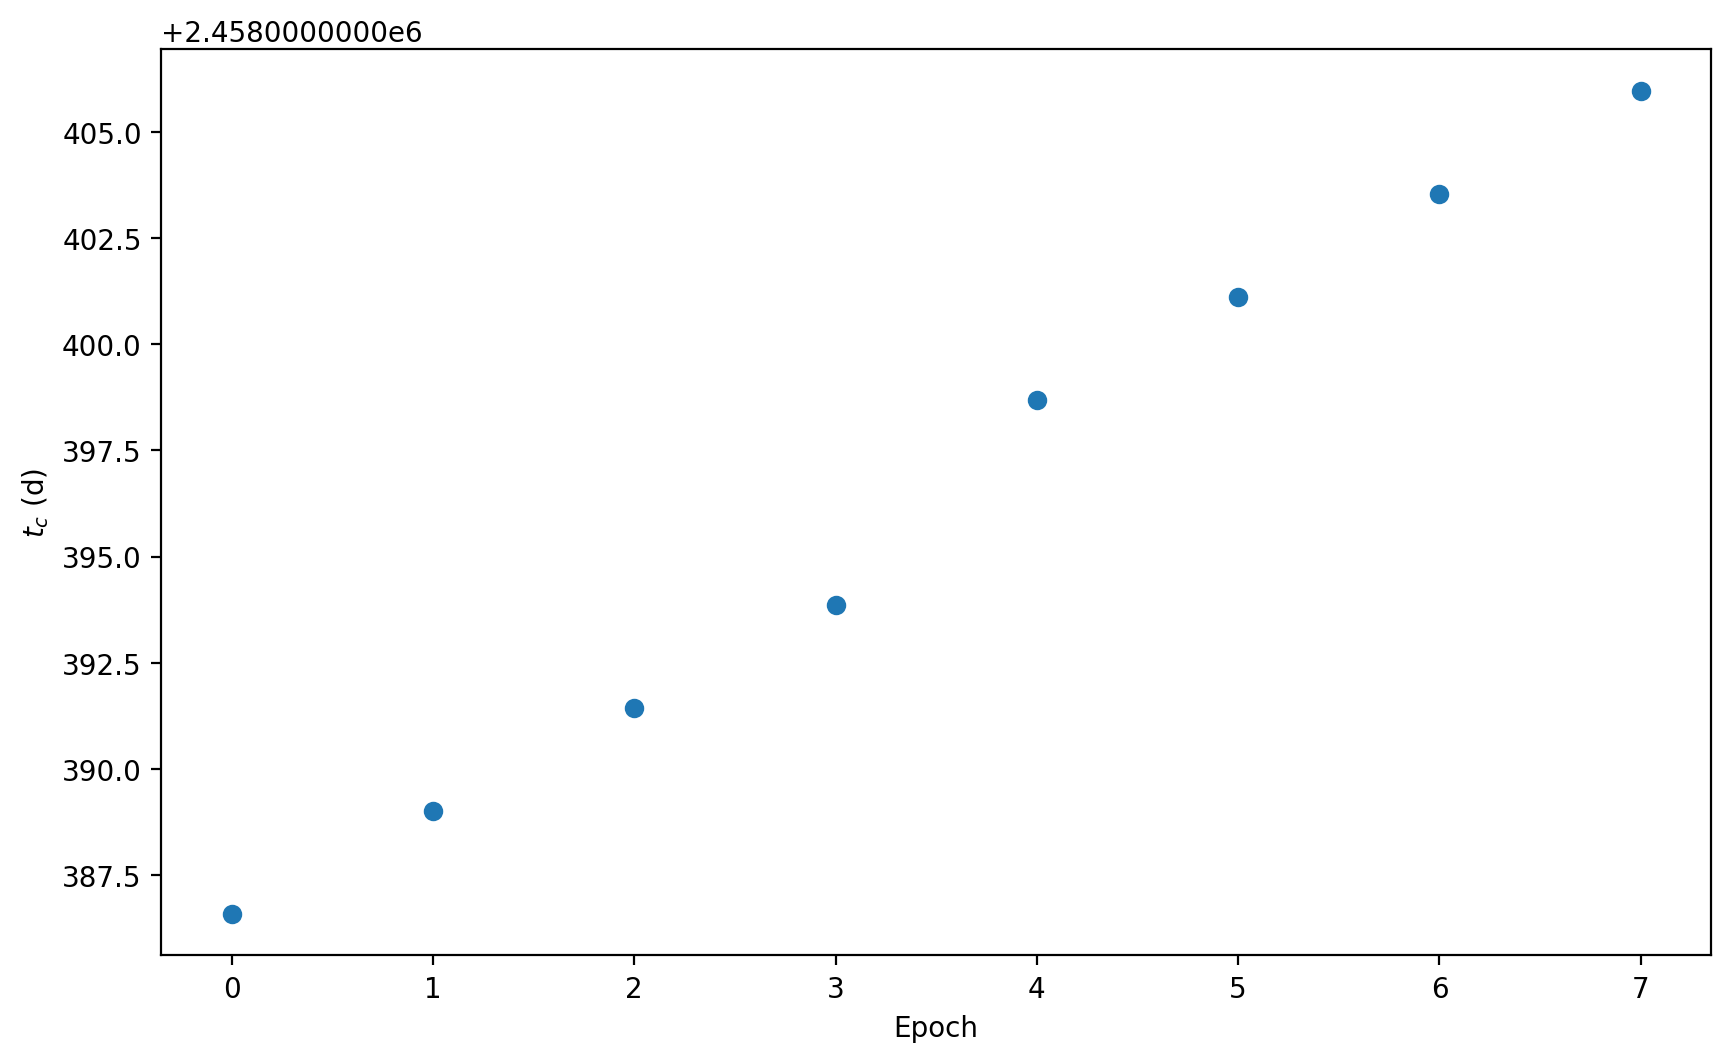

In [46]:
def getn(unfloat):
    return unfloat.n

def gets(unfloat):
    return unfloat.s

getn_v = np.vectorize(getn)
gets_v = np.vectorize(gets)

fig = plt.subplots(figsize=(10,6),dpi=200)
# plt.plot(epochs,getn_v(tcs),'.')
plt.errorbar(np.arange(len(times)),getn_v(tcs),yerr=gets_v(tcs),fmt='o')
plt.xlabel('Epoch')
plt.ylabel(r'$t_c$ (d)')

plt.show()

In [47]:
epoch_v = np.vectorize(epoch)
epochs = epoch_v(getn_v(tcs),zero_epoch.n, period.n)

# tcs = np.insert(tcs,0,wasp44b.lpf.zero_epoch)
# epochs = np.insert(epochs,0,0)
re = tcs - epochs * period - zero_epoch

In [48]:
re

array([0.008361129090189934+/-0.01066122652417882,
       0.010755129624158144+/-0.01067087972293639,
       0.007789358496665955+/-0.01066496860234981,
       0.00995210837572813+/-0.010765929282274116,
       0.008115062024444342+/-0.010705942067719479,
       0.008910801727324724+/-0.010713443355421367,
       0.010358111932873726+/-0.010717433634350279,
       0.00863357912749052+/-0.010753282512718405], dtype=object)

Text(0, 0.5, 'residual (s)')

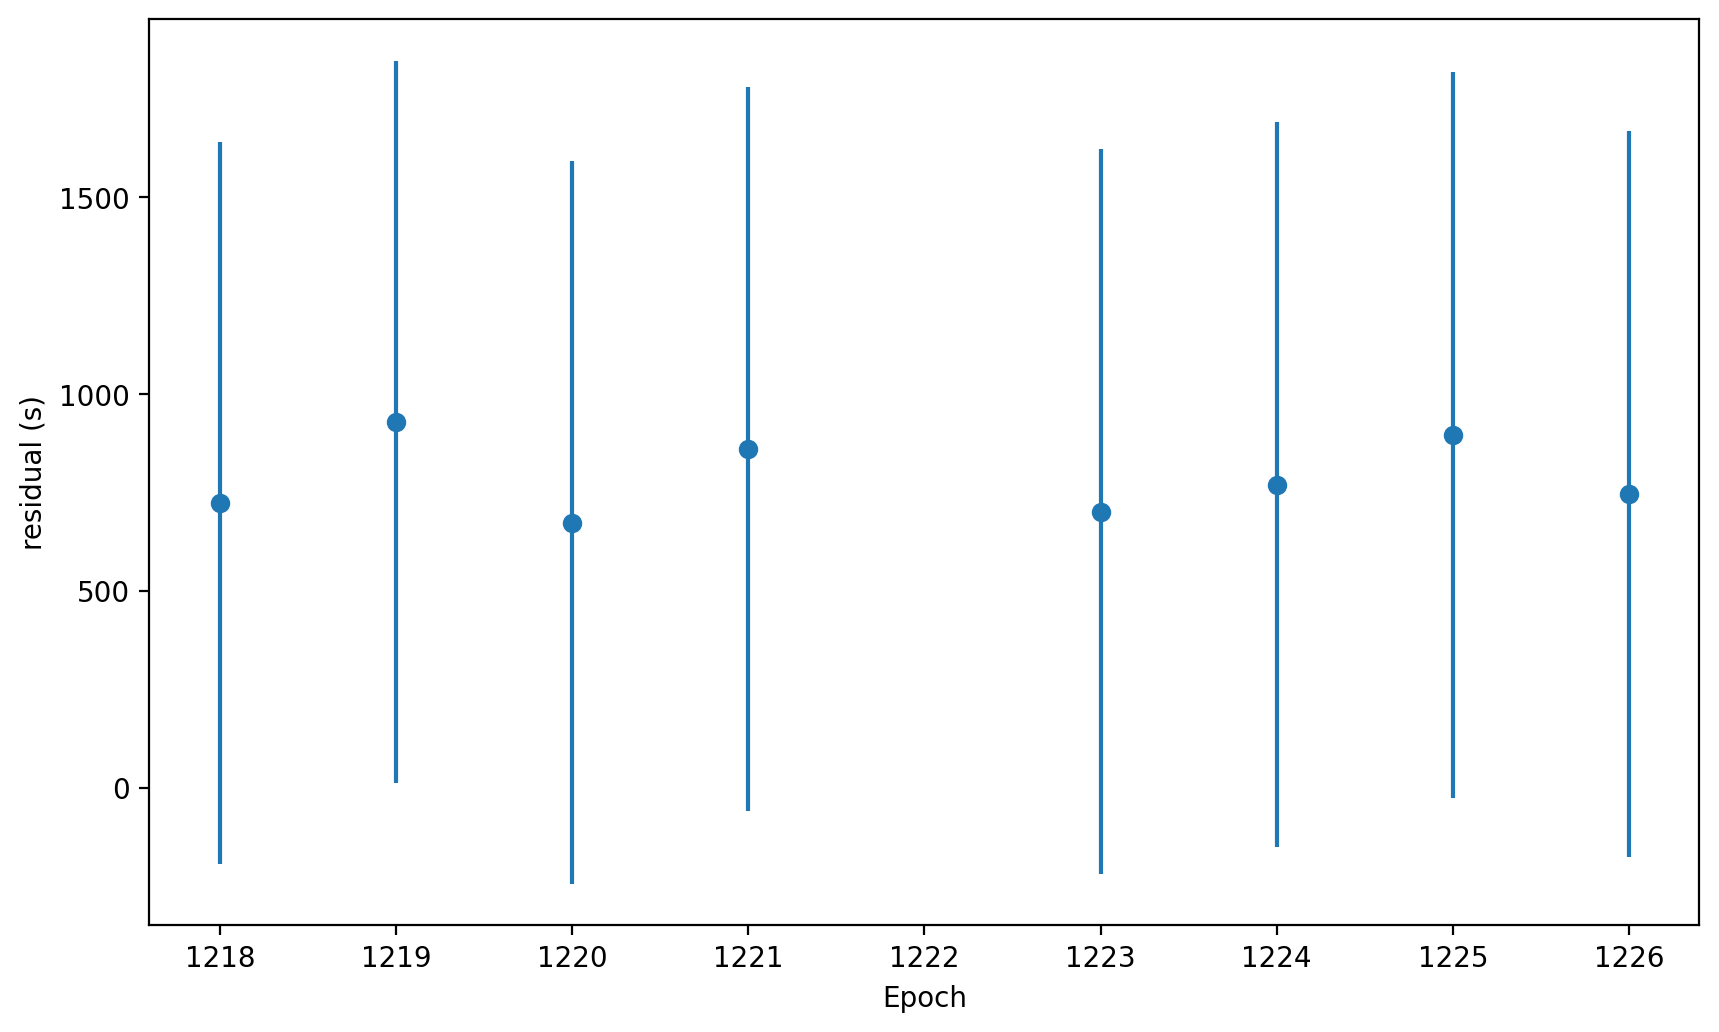

In [35]:
re = getn_v(tcs) - epochs * period - zero_epoch

daytos = 24*60*60
fig = plt.subplots(figsize=(10,6),dpi=200)
plt.errorbar(epochs,getn_v(re)*daytos,yerr=gets_v(re)*daytos,linestyle='',marker='.',markersize=12)

# plt.plot(epochs,getn_v(re)*daytos,linestyle='',marker='.',markersize=12)
plt.xlabel('Epoch')
plt.ylabel('residual (s)')